In [1]:
import os
os.chdir('.')
os.getcwd()

'/home/tako/Kasetsart/statistics'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
class_names = iris.target_names
print(class_names)
df.head()

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
output_var = 'target'
input_vars = df.columns.tolist()
input_vars.remove(output_var)
input_vars

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
X = df[input_vars]
y = df[output_var] 
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Linear Discriminant Analysis

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
selected_n_components = 2 # can be adjusted
lda = LinearDiscriminantAnalysis(n_components=selected_n_components)

X_lda = lda.fit_transform(X_scaled, y)

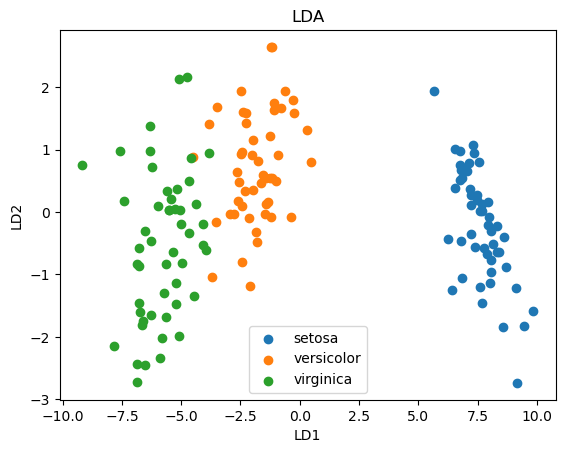

In [7]:
target_names = class_names
plt.figure()
for label, name in enumerate(target_names):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=name
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("LDA")
plt.legend()
plt.show()

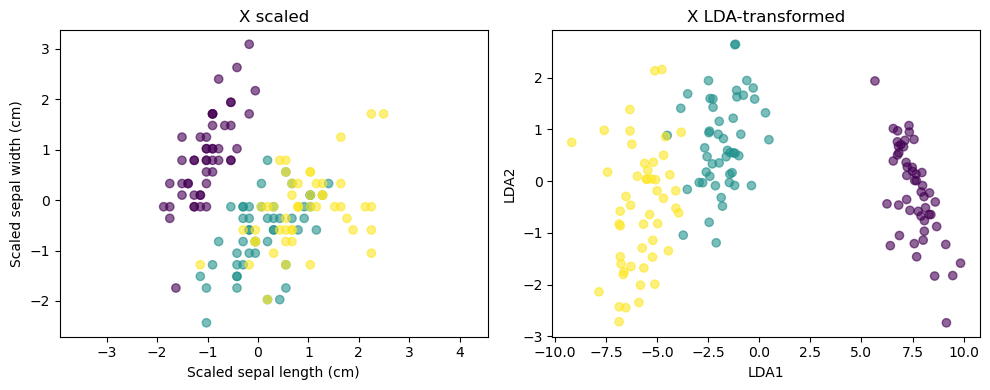

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

y = df[output_var]
var1_index = 0
var2_index = 1

# Left figure: X=var1, Y = var2
axs[0].scatter(X_scaled[:, var1_index], X_scaled[:, var2_index], c=y, alpha=0.6)
axs[0].set_title("X scaled")
axs[0].set_xlabel('Scaled '+input_vars[var1_index])
axs[0].set_ylabel('Scaled '+input_vars[var2_index])
axs[0].axis("equal")

# Left figure: X=LDA1, Y = LDA2
scatter2 = axs[1].scatter(X_lda[:, var1_index], X_lda[:, var2_index], c=y, alpha=0.6)
axs[1].set_title("X LDA-transformed")
axs[1].set_xlabel("LDA1")
axs[1].set_ylabel("LDA2")

plt.tight_layout()
plt.show()

In [9]:
# How different variables contributes class separation
print("Discriminant coefficients (w):")
print(lda.scalings_)

Discriminant coefficients (w):
[[ 0.68448644 -0.01989153]
 [ 0.66659193 -0.94029176]
 [-3.87282074  1.63962597]
 [-2.13508598 -2.15691008]]


In [10]:
# Interpret variable contribution to class separation
# Larger absolute value = stronger contribution to class separation
# Direction indicates which class side
# Compare coefficients within the same discriminant axis

scalings_df = pd.DataFrame(
    lda.scalings_,
    index=X.columns,
    columns=[f"LD{i+1}" for i in range(lda.scalings_.shape[1])]
)

scalings_df.abs().sort_values(by="LD1", ascending=False)

,LD1,LD2
petal length (cm),3.872821,1.639626
petal width (cm),2.135086,2.156910
sepal length (cm),0.684486,0.019892
sepal width (cm),0.666592,0.940292


In [11]:
# LDA scaling can be "roughly" used to rank variables by magnitude
# Note: To get exact and better ranking, perform feature selection instead.  
#       LDA is mainly used to find projection for best separation, not for feature importance.

feature_importance = scalings_df.abs().sum(axis=1)
feature_importance.sort_values(ascending=False)

petal length (cm)    5.512447
petal width (cm)     4.291996
sepal width (cm)     1.606884
sepal length (cm)    0.704378
dtype: float64

In [12]:
# Classifier coefficients
# Magnitude of coefficients: Which  variable is important for which class
# Sign of coefficients: Direction of separation
coef_df = pd.DataFrame(
    lda.coef_,
    columns=input_vars,
    index=class_names
)
coef_df

# Result interpretation
# Setosa: small petal length & width
# Virginica: large petal length & width
# Versicolor: intermediate

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,5.211578,5.273453,-29.815608,-15.778857
versicolor,-1.263701,-1.901001,8.261573,2.326624
virginica,-3.947878,-3.372451,21.554036,13.452234


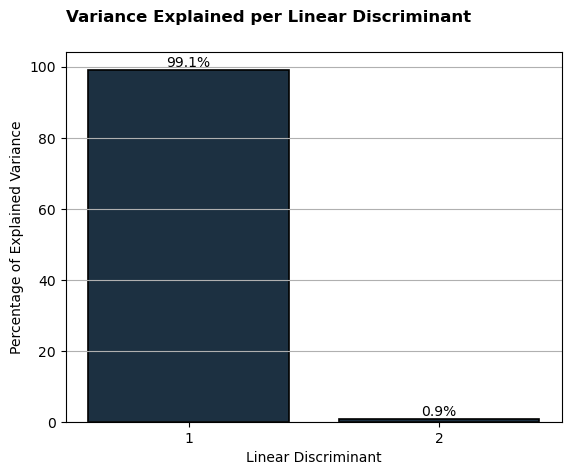

In [13]:
# LDA Explained Variance Plot
# LDA bar height = proportion of between-class variance explained
# Note: PCA bar height = total data variance != LDA bar height 

plot_y = [val * 100 for val in lda.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Linear Discriminant")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Linear Discriminant", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

In [14]:
# Create a Grid of Points
temp_X = X.iloc[:, :2]   # first two features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
temp_X_scaled = scaler.fit_transform(temp_X)
temp_lda = LinearDiscriminantAnalysis()
temp_lda.fit(temp_X_scaled, y)

x_min, x_max = temp_X_scaled[:, 0].min() - 0.5, temp_X_scaled[:, 0].max() + 0.5
y_min, y_max = temp_X_scaled[:, 1].min() - 0.5, temp_X_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
grid = np.c_[xx.ravel(), yy.ravel()]

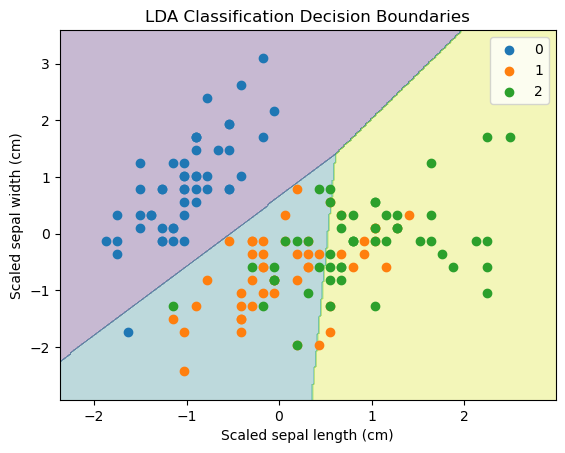

In [15]:
# plot Decision regions

var1_index = 0
var2_index = 1

Z = temp_lda.predict(grid)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)

# Training points
for class_label in np.unique(y):
    plt.scatter(
        temp_X_scaled[y == class_label][:, var1_index],
        temp_X_scaled[y == class_label][:, var2_index],
        label=class_label
    )

plt.xlabel('Scaled '+input_vars[var1_index])
plt.ylabel('Scaled '+input_vars[var2_index])
plt.title("LDA Classification Decision Boundaries")
plt.legend()
plt.show()

### Principal Component Analysis 

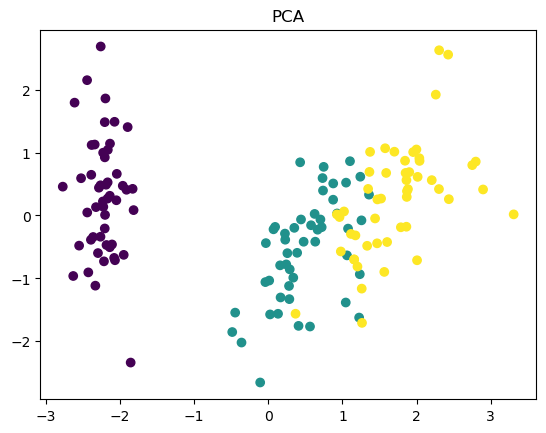

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.title("PCA")
plt.show()

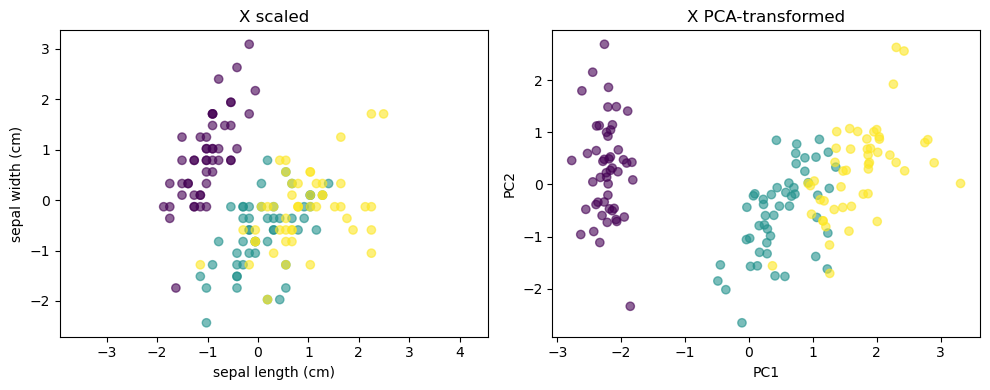

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

y = df[output_var]
var1_index = 0
var2_index = 1

# Left figure: X=var1, Y = var2
axs[0].scatter(X_scaled[:, var1_index], X_scaled[:, var2_index], c=y, alpha=0.6)
axs[0].set_title("X scaled")
axs[0].set_xlabel(input_vars[var1_index])
axs[0].set_ylabel(input_vars[var2_index])
axs[0].axis("equal")

# Left figure: X=PC1, Y = PC2
scatter2 = axs[1].scatter(X_pca[:, var1_index], X_pca[:, var2_index], c=y, alpha=0.6)
axs[1].set_title("X PCA-transformed")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

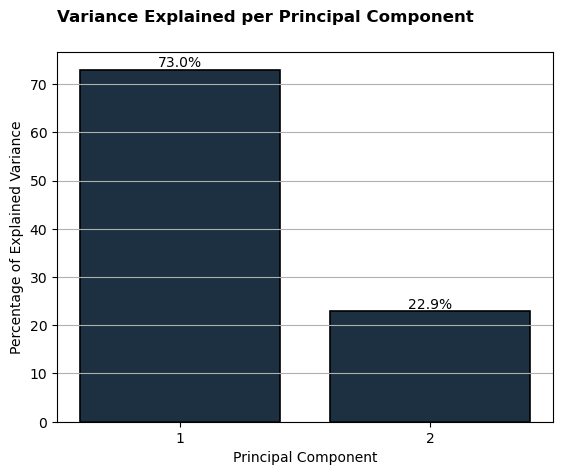

In [18]:
plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

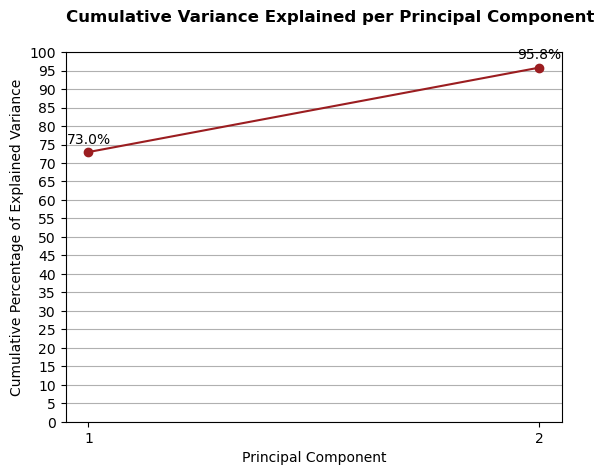

In [19]:
exp_var = [val * 100 for val in pca.explained_variance_ratio_]
plot_y = [sum(exp_var[:i+1]) for i in range(len(exp_var))]
plot_x = range(1, len(plot_y) + 1)

plt.plot(plot_x, plot_y, marker="o", color="#9B1D20")
for x, y in zip(plot_x, plot_y):
    plt.text(x, y + 1.5, f"{y:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Percentage of Explained Variance")
plt.title("Cumulative Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)

plt.yticks(range(0, 101, 5))
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

In [20]:
# To see contribution of each original variable on each PC
# Larger absolute value = stronger contribution to that PC
# Direction (+/-) shows correlation direction
# Meaningful within the same PC
# Do not use this to look at importance of variables

components_df = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
components_df

,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942


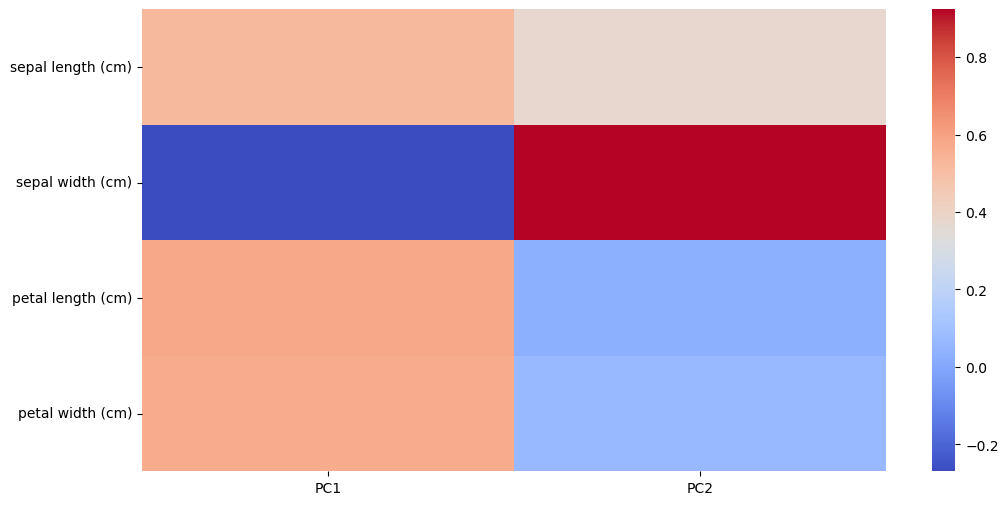

In [21]:
plt.figure(figsize=(12,6))
sns.heatmap(components_df,cmap='coolwarm')
plt.show()

# y axis = each variable
# The result shows that each variable contributes to each principal component